In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

Step 1: Choose a provided dataset and determine whether the task is regression or classification.

this dataset is a classification, 'Cause the target values is No or Yes.

Step 2: Perform brief EDA, then preprocess: handle missing values, encode categoricals, and scale features 
(fit on train only).

first I load the dataset.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


now I will do the data cleaning step.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7037 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             6
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      5
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["Partner"] = df["Partner"].fillna(df["Partner"].mode()[0])
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].median())

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print(df.duplicated().sum())

0


In [43]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

in this step I will do the EDA.

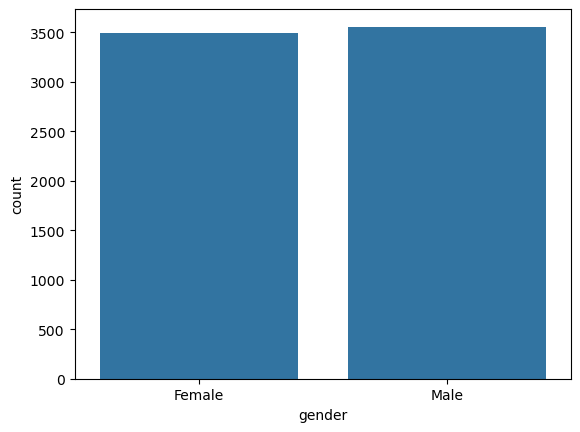

In [12]:
sns.countplot(data=df, x="gender")
plt.show()

here we can see that number of female and male is approximatly the same(~3500).

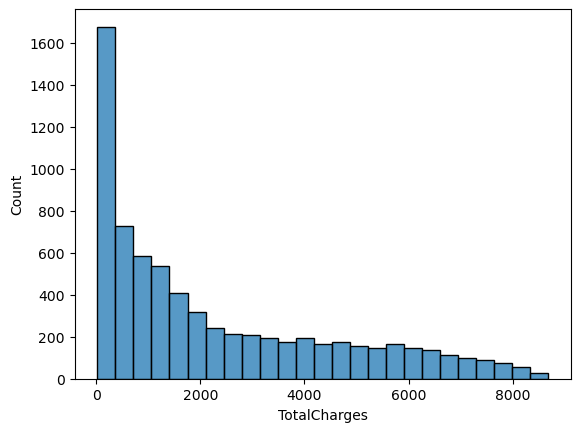

In [13]:
sns.histplot(data=df, x="TotalCharges")
plt.show()

we can see here that most of people have Total Charge < 500.

In [17]:
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["TotalCharges"] < Q1 - 1.5*IQR) | (df["TotalCharges"] > Q3 + 1.5*IQR)]
outliers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


I thought that there is an outliers so I check it, but Total Charges don't have any outliers.

now lets see the correlations.

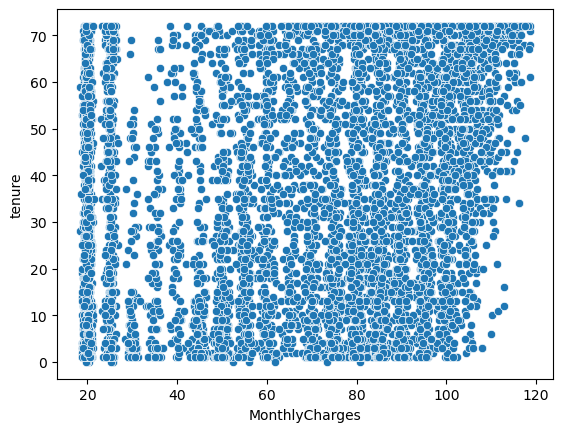

In [19]:
sns.scatterplot(data=df, x="MonthlyCharges", y="tenure")
plt.show()

there is no clear linear relationship between MonthlyCharges and tenure,the points are broadly scattered across all tenure values regardless of monthly charge.

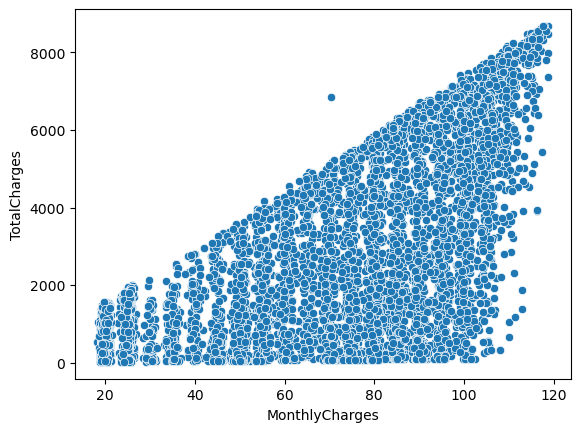

In [20]:
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges")
plt.show()

here we can see that there is a positive but non-linear relationship between MonthlyCharges and TotalCharges. The triangular shape of the scatter suggests that TotalCharges depends not only on MonthlyCharges but also on tenure, customers with the same monthly rate can have very different total charges depending on how long they've been subscribed. TotalCharges ≈ MonthlyCharges × tenure.

now I will do incoding 'Cause the model can use only numerical data.

In [21]:
df["gender"] = df["gender"].replace({ "Male" : 1, "Female" : 0})

C:\Users\darag\AppData\Local\Temp\ipykernel_4644\621520322.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"] = df["gender"].replace({ "Male" : 1, "Female" : 0})


In [39]:
df["Partner"] = df["Partner"].replace({ "Yes" : 1, "No" : 0})
df["Dependents"] = df["Dependents"].replace({ "Yes" : 1, "No" : 0})
df["PhoneService"] = df["PhoneService"].replace({ "Yes" : 1, "No" : 0})
df["MultipleLines"] = df["MultipleLines"].replace({ "Yes" : 1, "No" : 0, "No phone service" : 0 })
df["OnlineSecurity"] = df["OnlineSecurity"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["OnlineBackup"] = df["OnlineBackup"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["DeviceProtection"] = df["DeviceProtection"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["TechSupport"] = df["TechSupport"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["StreamingTV"] = df["StreamingTV"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["StreamingMovies"] = df["StreamingMovies"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })
df["PaperlessBilling"] = df["PaperlessBilling"].replace({ "Yes" : 1, "No" : 0 })
df["StreamingTV"] = df["StreamingTV"].replace({ "Yes" : 1, "No" : 0, "No internet service" : 0 })

C:\Users\darag\AppData\Local\Temp\ipykernel_4644\1396755255.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Partner"] = df["Partner"].replace({ "Yes" : 1, "No" : 0})
C:\Users\darag\AppData\Local\Temp\ipykernel_4644\1396755255.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Dependents"] = df["Dependents"].replace({ "Yes" : 1, "No" : 0})
C:\Users\darag\AppData\Local\Temp\ipykernel_4644\1396755255.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain th

I put 0 to options (No,No internet service,No phone service) 'Cause the model already know from PhoneService and InternetService who doesn't have internet and phone services, so the model doesn't lose any important info.

In [41]:
df = pd.get_dummies(df, columns=["InternetService", "Contract", "PaymentMethod"])

In [45]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

C:\Users\darag\AppData\Local\Temp\ipykernel_4644\2364848822.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   MultipleLines                            7043 non-null   int64  
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

I will split the dataset to train and test data to prepare the data for fitting and prediction. we do this step to make sure the data don't remember the target value in test set when we do the prediction.

In [51]:
X = df.drop(columns=["customerID", "Churn"])
Y = df["Churn"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

now lets scale the numerical columns.

In [57]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,-1.025166,-0.437749,-0.968546,1.532186,-0.465683,0.329573,-0.860523,1.580942,-0.733828,1.384796,...,1.380442,-0.887057,-0.524081,-1.099339,1.910109,-0.558353,-0.530678,-0.527656,-0.709650,1.84247
1623,-1.025166,-0.437749,-0.968546,-0.652662,0.885537,0.329573,1.162083,-0.632534,1.362717,-0.722128,...,-0.724405,1.127324,-0.524081,-1.099339,-0.523530,1.790982,1.884380,-0.527656,-0.709650,-0.54275
6074,0.975452,-0.437749,1.032476,-0.652662,-1.284605,-3.034225,-0.860523,-0.632534,-0.733828,-0.722128,...,1.380442,-0.887057,-0.524081,0.909638,-0.523530,-0.558353,-0.530678,-0.527656,1.409146,-0.54275
1362,0.975452,-0.437749,-0.968546,-0.652662,-1.161766,0.329573,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.724405,1.127324,-0.524081,0.909638,-0.523530,-0.558353,-0.530678,-0.527656,1.409146,-0.54275
6754,0.975452,-0.437749,-0.968546,1.532186,-1.325551,0.329573,1.162083,1.580942,1.362717,-0.722128,...,1.380442,-0.887057,-0.524081,-1.099339,-0.523530,1.790982,1.884380,-0.527656,-0.709650,-0.54275


Step 3: Train at least two appropriate models and evaluate them with a suitable metric against a baseline.

In [61]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_scaled, Y_train)
predictions1 = model1.predict(X_test_scaled)
probabilities = model1.predict_proba(X_test_scaled)

In [63]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_scaled, Y_train)
predictions2 = model2.predict(X_test_scaled)

In [66]:
model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(X_train_scaled, Y_train)
predictions3 = model3.predict(X_test_scaled)

In [68]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, Y_train)
predictions_baseline = baseline.predict(X_test_scaled)

In [72]:
print(classification_report(Y_test, predictions1))
print()
print(classification_report(Y_test, predictions2))
print()
print(classification_report(Y_test, predictions3))
print()
print(classification_report(Y_test, predictions_baseline))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.64      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.57      0.51      0.54       373

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.76      0.77      0.77      1409


              pr

C:\Users\darag\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\darag\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\darag\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [75]:
from sklearn.metrics import f1_score

models_results = {
    "Logistic Regression": predictions1,
    "RandomForest Classifier": predictions2,
    "KNeighbors Classifier": predictions3,
    "Baseline": predictions_baseline
}

comparison_table = pd.DataFrame({
    "Model": list(models_results.keys()),
    "F1-score": [f1_score(Y_test, preds) for preds in models_results.values()]
})

print(comparison_table)

                     Model  F1-score
0      Logistic Regression  0.640000
1  RandomForest Classifier  0.546296
2    KNeighbors Classifier  0.541608
3                 Baseline  0.000000


Step 4: Select the better model, justify the choice, and document the full pipeline in a narrated notebook.

Since the goal of this prediction is to identify which customers will leave the company, so I compared the F1-score for class 1 (Churn = Yes) only. we can see that the baseline failed this task with f1 score = 0.00, as it always predicts the majority class and never identifies a churning customer.
best model for this prediction is Logistic Regression 'Cause it give us the best f1 for those who will leave the company (0.64), other models RandomForest = 0.546 and KNN = 0.542 perform well but not enough like Logistic Regression.
Therefore, I selected Logistic Regression as the final model.